## ES98A Assignment 2
Author: Jabir Hussain (2007942)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
%config InlineBackend.figure_format='retina'

np.random.seed(2007942)

In [ ]:

m = sigma = 0.5
Q_true = 1.868246  # from the assignment sheet

# ----- definitions -----
def rho_x(x):
    """PDF ρ_x(x) from eq. (2.1); symmetric 'back-to-back' lognormal."""
    x = np.asarray(x)
    ax = np.abs(x)
    out = np.zeros_like(ax)
    mask = ax > 0.0
    z = (np.log(ax[mask]) - m) / sigma
    out[mask] = np.exp(-0.5 * z**2) / (np.sqrt(8*np.pi) * sigma * ax[mask])
    return out

def q(x):
    return np.abs(x) + 0.5*x

def integrand(x):
    return q(x) * rho_x(x)


In [12]:
# ----- integration settings -----
L = 8.0                              # large enough interval (truncation negligible)
Ns = np.array([50, 100, 200, 400, 800, 1600, 3200])

# integrate on [0,L] and double for symmetry
def integrate_scipy(L, N):
    x = np.linspace(-L, L, N)
    return trapezoid(integrand(x), x)

# ----- convergence study -----
QNs = np.array([integrate_scipy(L, N) for N in Ns])
ENs = QNs - Q_true

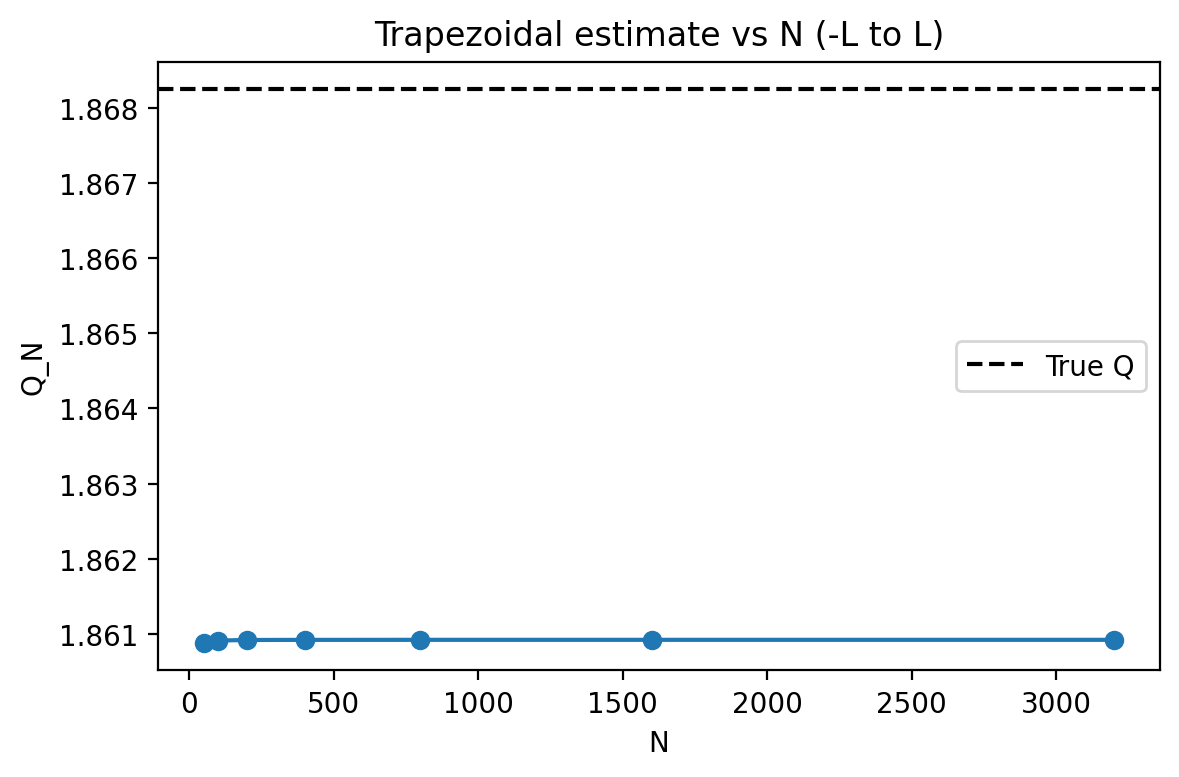

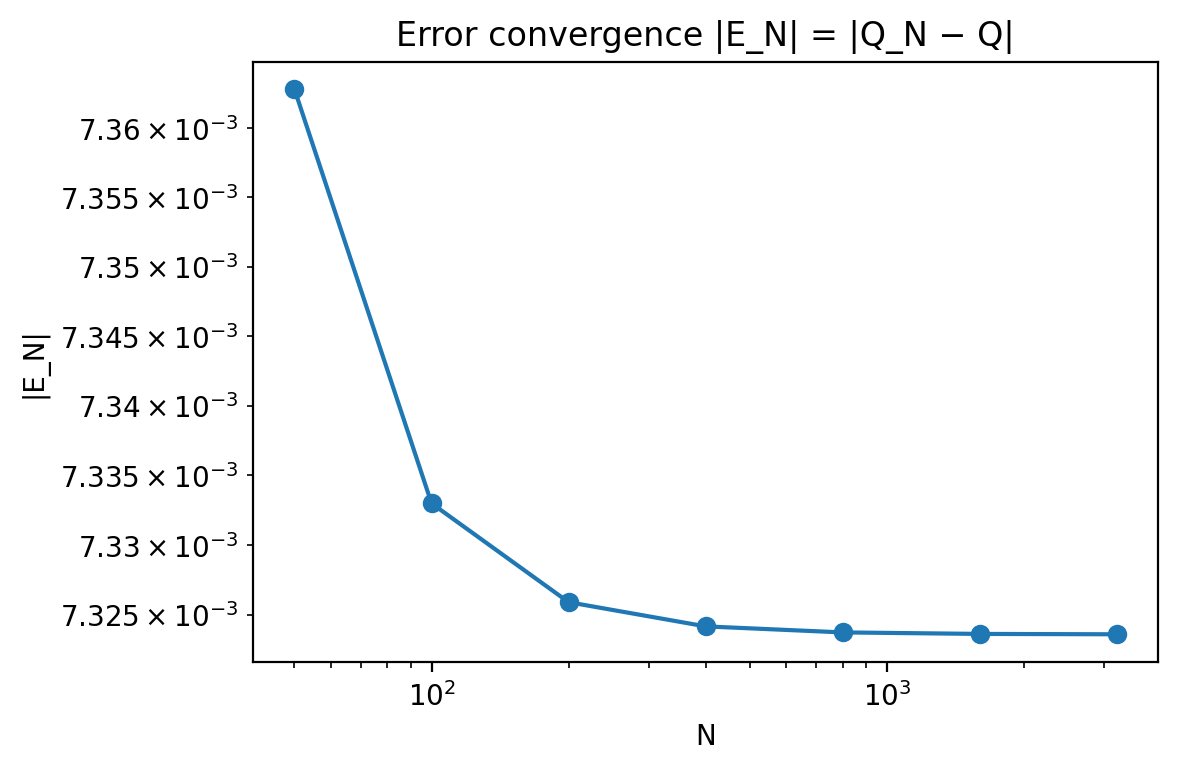

In [13]:
# ----- plots -----
plt.figure(figsize=(6,4))
plt.plot(Ns, QNs, 'o-')
plt.axhline(Q_true, ls='--', color='k', label='True Q')
plt.xlabel('N'); plt.ylabel('Q_N')
plt.title('Trapezoidal estimate vs N (-L to L)')
plt.legend(); plt.tight_layout()

plt.figure(figsize=(6,4))
plt.loglog(Ns, np.abs(ENs), 'o-')
plt.xlabel('N'); plt.ylabel('|E_N|')
plt.title('Error convergence |E_N| = |Q_N − Q|')
plt.tight_layout()
plt.show()